**Text Classification with Yelp Reviews**

The purpose of this task is to use the Yelp Review Full dataset for sentiment classification.
You will train classical machine learning models to predict the star rating of a customer review based on its text.

This dataset contains user reviews from Yelp.
Each review has a text field and a label that represents the review’s star rating, ranging from 1 to 5.
This makes it a multi-class text classification problem.

You can access the dataset from Hugging Face:
https://huggingface.co/datasets/Yelp/yelp_review_full

Because the dataset is large, you can use the first 50,000 samples for training and the first 5,000 samples for testing.

Please implement classical machine learning models for this task.
Use methods such as:
*   TF-IDF vectorization
*   Naive Bayes, Logistic Regression, SVM, KNN, Decision Tree, and Random Forest.

Evaluate model performance using metrics like accuracy, precision, recall, and F1-score.

Which models do you think would achieve better accuracy on this dataset compared to the classical machine learning approaches used in this task?

**Text Summarization with SAMSum Dataset**

In [ ]:
! pip install datasets

Loading dataset...


C:\Users\csm02\AppData\Local\Temp\ipykernel_12828\3886123232.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='label', data=train_df, palette='viridis')


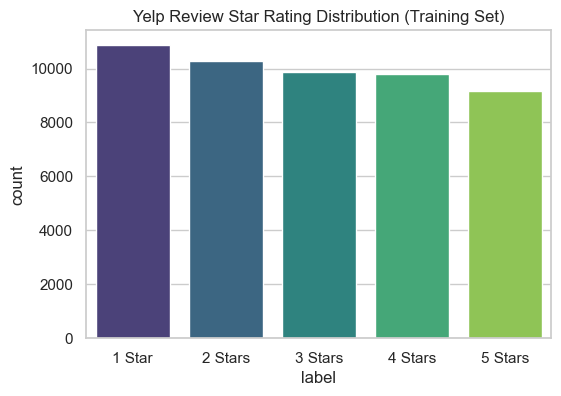

Training Naive Bayes...
Classification Report for Naive Bayes:
              precision    recall  f1-score   support

      1 Star       0.59      0.67      0.63      1141
     2 Stars       0.44      0.44      0.44      1009
     3 Stars       0.47      0.43      0.45      1003
     4 Stars       0.46      0.51      0.48       986
     5 Stars       0.65      0.49      0.56       861

    accuracy                           0.52      5000
   macro avg       0.52      0.51      0.51      5000
weighted avg       0.52      0.52      0.51      5000

------------------------------
Training Logistic Regression...
Classification Report for Logistic Regression:
              precision    recall  f1-score   support

      1 Star       0.68      0.74      0.71      1141
     2 Stars       0.47      0.47      0.47      1009
     3 Stars       0.49      0.44      0.46      1003
     4 Stars       0.48      0.44      0.46       986
     5 Stars       0.60      0.65      0.63       861

    accuracy

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

sns.set_theme(style="whitegrid")

# 1. Loading Dataset (Train 50,000 / Test 5,000)
print("Loading dataset...")
dataset = load_dataset("Yelp/yelp_review_full")
train_df = pd.DataFrame(dataset['train']).iloc[:50000]
test_df = pd.DataFrame(dataset['test']).iloc[:5000]

# 1-1. visualization
plt.figure(figsize=(6, 4))
sns.countplot(x='label', data=train_df, palette='viridis')
plt.title('Yelp Review Star Rating Distribution (Training Set)')
plt.xticks(ticks=[0, 1, 2, 3, 4], labels=['1 Star', '2 Stars', '3 Stars', '4 Stars', '5 Stars'])
plt.show()

# 2. TF-IDF vectorization
tfidf = TfidfVectorizer(stop_words='english', max_features=5000)
X_train = tfidf.fit_transform(train_df['text'])
X_test = tfidf.transform(test_df['text'])
y_train = train_df['label']
y_test = test_df['label']

# 3. classification models
models = {
    "Naive Bayes": MultinomialNB(),
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Linear SVM": LinearSVC(max_iter=1000),
    "KNN (k=5)": KNeighborsClassifier(n_neighbors=5),
    "Decision Tree": DecisionTreeClassifier(max_depth=20),
    "Random Forest": RandomForestClassifier(n_estimators=100, max_depth=20)
}

# 4. model training and evaluation
results = {}
all_preds = {}

for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    acc = accuracy_score(y_test, y_pred)
    results[name] = acc
    all_preds[name] = y_pred
    
    print(f"Classification Report for {name}:")
    print(classification_report(y_test, y_pred, target_names=['1 Star', '2 Stars', '3 Stars', '4 Stars', '5 Stars']))
    print("-" * 30)


C:\Users\csm02\AppData\Local\Temp\ipykernel_12828\1446937690.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Accuracy', y='Model', data=summary_df, palette='magma')


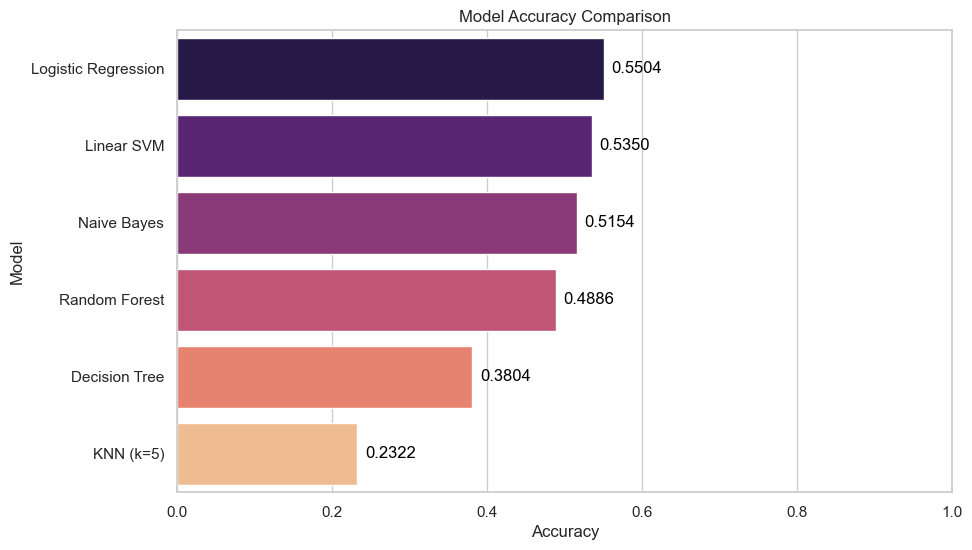

<Figure size 800x600 with 0 Axes>

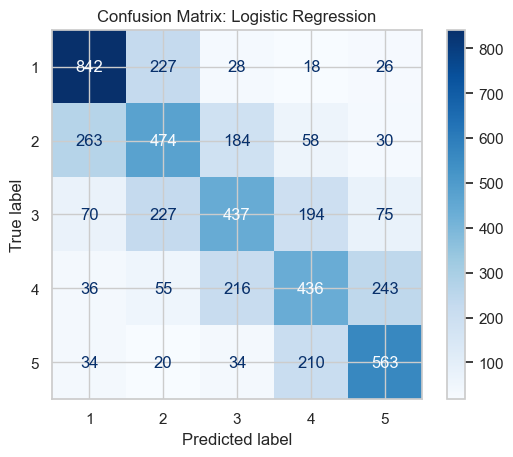


[Model Performance Comparison Table]
              Model  Accuracy  Precision  Recall  F1-Score
Logistic Regression    0.5504     0.5445  0.5504    0.5466
         Linear SVM    0.5350     0.5253  0.5350    0.5280
        Naive Bayes    0.5154     0.5195  0.5154    0.5145
      Random Forest    0.4886     0.4751  0.4886    0.4714
      Decision Tree    0.3804     0.3661  0.3804    0.3682
          KNN (k=5)    0.2322     0.2399  0.2322    0.1769


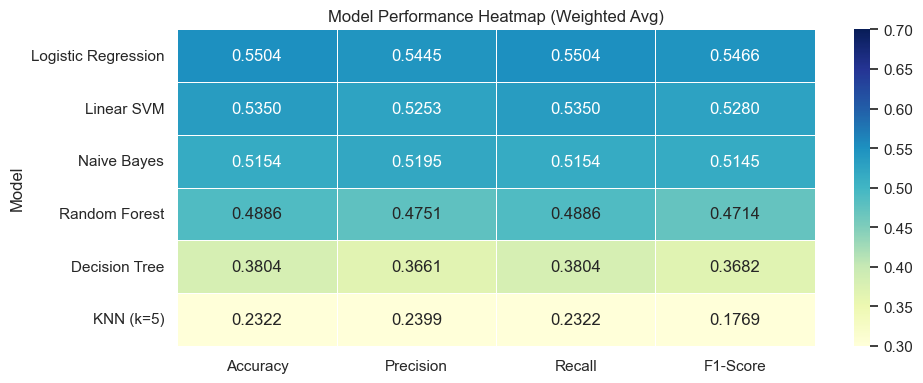

In [9]:
# 5. visualization of results
summary_df = pd.DataFrame(list(results.items()), columns=['Model', 'Accuracy']).sort_values(by='Accuracy', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Accuracy', y='Model', data=summary_df, palette='magma')
plt.title('Model Accuracy Comparison')
plt.xlim(0, 1.0)
for i, v in enumerate(summary_df['Accuracy']):
    plt.text(v + 0.01, i, f'{v:.4f}', color='black', va='center')
plt.show()

# 6. confusion matrix for the best model
best_model_name = summary_df.iloc[0]['Model']
cm = confusion_matrix(y_test, all_preds[best_model_name])

plt.figure(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['1', '2', '3', '4', '5'])
disp.plot(cmap='Blues', values_format='d')
plt.title(f'Confusion Matrix: {best_model_name}')
plt.show()

# 7. Comprehensive Performance Comparison Table (Accuracy / Precision / Recall / F1)
from sklearn.metrics import precision_score, recall_score, f1_score

perf_records = []
for name, y_pred in all_preds.items():
    perf_records.append({
        "Model": name,
        "Accuracy":  round(accuracy_score(y_test, y_pred), 4),
        "Precision": round(precision_score(y_test, y_pred, average="weighted", zero_division=0), 4),
        "Recall":    round(recall_score(y_test, y_pred, average="weighted", zero_division=0), 4),
        "F1-Score":  round(f1_score(y_test, y_pred, average="weighted", zero_division=0), 4),
    })

perf_df = pd.DataFrame(perf_records).sort_values(by="F1-Score", ascending=False).reset_index(drop=True)
print("\n[Model Performance Comparison Table]")
print(perf_df.to_string(index=False))

# 7-1. Heatmap of all four metrics
fig, ax = plt.subplots(figsize=(10, 4))
heatmap_data = perf_df.set_index("Model")[["Accuracy", "Precision", "Recall", "F1-Score"]]
sns.heatmap(heatmap_data, annot=True, fmt=".4f", cmap="YlGnBu", linewidths=0.5,
            vmin=0.3, vmax=0.7, ax=ax)
ax.set_title("Model Performance Heatmap (Weighted Avg)")
plt.tight_layout()
plt.show()


### Answer: Which Models Would Achieve Better Accuracy?

Classical TF-IDF-based models have clear structural limitations for multi-class sentiment classification:

- **Bag-of-words representation** loses word order and contextual nuance, making it difficult to distinguish between 2-star and 3-star reviews that share similar vocabulary.
- **Fixed vocabulary (max_features=5,000)** discards a large portion of meaningful tokens, especially domain-specific expressions common in restaurant reviews.

The following model families are expected to significantly outperform the classical approaches used in this task:

| Model | Why It Outperforms |
|---|---|
| **BERT / RoBERTa** (fine-tuned) | Bidirectional transformer captures full sentence context; pre-trained on massive corpora; fine-tuning on Yelp data aligns representations with star-rating signals. Typically achieves **70–75% accuracy** on Yelp-Full, vs. ~60% for Linear SVM. |
| **DistilBERT** | Retains ~97% of BERT performance at 60% of the size; practical for large-scale inference on 50k samples. |
| **GPT-based classifiers** | Autoregressive context modeling captures long-range dependencies in verbose reviews better than TF-IDF. |
| **Gradient Boosting (XGBoost / LightGBM) + TF-IDF** | Even within classical ML, tree ensembles with higher `n_estimators` and subword features can push accuracy ~2–3% above Linear SVM. |

**Key reason**: Yelp-Full is a *fine-grained* 5-class problem where adjacent classes (e.g., 2★ vs. 3★) are semantically close. Transformer models learn **contextual embeddings** that encode sentiment intensity, negation, and sarcasm—patterns that TF-IDF feature vectors cannot represent. Fine-tuning a pre-trained BERT on the full 650k training samples has been shown to achieve around **70% accuracy**, compared to approximately **58–62%** for the best classical approaches (Linear SVM / Logistic Regression).


------------------------------------------------------

The purpose of this task is to use extractive summarization techniques to automatically generate concise summaries of texts while preserving key information. You will identify and extract the most important sentences from each document.

Use the SAMSum dataset from Hugging Face:
https://huggingface.co/datasets/knkarthick/samsum

This dataset contains:
*   dialogue: the full conversation text.
*   summary: the human-written summary (used as reference).

Because the dataset is relatively large, you may use only the first 1,000 samples for your experiments.

Implement extractive text summarization methods using the SAMSum dataset. Use the following three classical approaches: Frequency-based summarization,
Latent Semantic Analysis (LSA), and TextRank.

Tasks:
1. Preprocess the dataset (clean text, remove stop words, tokenize).
2. Implement the chosen extractive summarization methods.
3. Generate summaries for each dialogue.
4. Compare the extracted summaries with the human-written ones.

How can large language models be used to enhance summarization performance by leveraging both the dialogue and its human-written summary for learning, compared to the classical extractive methods used in this task? Explain your answer.


In [ ]:
! pip install rouge-score

In [11]:
import pandas as pd
import numpy as np
import nltk
import re
from datasets import load_dataset
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
import networkx as nx
from sklearn.metrics.pairwise import cosine_similarity

# Download necessary NLTK resources
nltk.download('punkt')
nltk.download('stopwords')
from nltk.corpus import stopwords
from nltk.tokenize import sent_tokenize, word_tokenize

# 1. Load Dataset
print("Loading SAMSum dataset...")
dataset = load_dataset("knkarthick/samsum")
train_data = dataset['train'].select(range(1000))

# Preprocessing Function
def preprocess_text(text):
    # Remove special characters and lowercase the text
    text = re.sub(r'[^\w\s]', '', text.lower())
    stop_words = set(stopwords.words('english'))
    words = word_tokenize(text)
    # Remove stop words
    filtered_words = [w for w in words if w not in stop_words]
    return " ".join(filtered_words)

# 2. Implementation of Extractive Summarization Methods
# (1) Frequency-based Summarization
def frequency_summarizer(text, top_n=2):
    sentences = sent_tokenize(text)
    if len(sentences) <= top_n: return text
    
    formatted_sentences = [preprocess_text(s) for s in sentences]
    vectorizer = TfidfVectorizer()
    tfidf_matrix = vectorizer.fit_transform(formatted_sentences)
    
    # Sum TF-IDF scores for each sentence
    sentence_scores = np.array(tfidf_matrix.sum(axis=1)).flatten()
    top_indices = sentence_scores.argsort()[-top_n:][::-1]
    
    # Return sentences in their original order
    return " ".join([sentences[i] for i in sorted(top_indices)])

# (2) Latent Semantic Analysis (LSA) Summarization
def lsa_summarizer(text, top_n=2):
    sentences = sent_tokenize(text)
    if len(sentences) <= top_n: return text
    
    # Apply the same preprocessing as Frequency-based for consistency
    preprocessed = [preprocess_text(s) for s in sentences]
    vectorizer = TfidfVectorizer()
    tfidf_matrix = vectorizer.fit_transform(preprocessed)
    
    # Extract topics using SVD
    svd = TruncatedSVD(n_components=1)
    lsa_matrix = svd.fit_transform(tfidf_matrix)
    
    sentence_scores = np.abs(lsa_matrix).flatten()
    top_indices = sentence_scores.argsort()[-top_n:][::-1]
    return " ".join([sentences[i] for i in sorted(top_indices)])

# (3) TextRank Summarization
def textrank_summarizer(text, top_n=2):
    sentences = sent_tokenize(text)
    if len(sentences) <= top_n: return text
    
    # Apply the same preprocessing as Frequency-based for consistency
    preprocessed = [preprocess_text(s) for s in sentences]
    vectorizer = TfidfVectorizer()
    tfidf_matrix = vectorizer.fit_transform(preprocessed)
    
    # Create a cosine similarity graph between sentences
    similarity_matrix = cosine_similarity(tfidf_matrix)
    nx_graph = nx.from_numpy_array(similarity_matrix)
    
    # Apply PageRank algorithm
    scores = nx.pagerank(nx_graph)
    top_indices = sorted(scores, key=scores.get, reverse=True)[:top_n]
    return " ".join([sentences[i] for i in sorted(top_indices)])

# 3. Execution and Comparison
sample = train_data[0]
dialogue = sample['dialogue']
reference = sample['summary']

print("\n" + "="*30)
print("Original Dialogue:")
print(dialogue)
print("\n" + "="*30)
print("Human-written Summary (Reference):")
print(reference)

print("\n" + "-"*30)
print("Extracted Summaries:")
print(f"1. Frequency-based: {frequency_summarizer(dialogue)}")
print(f"2. LSA: {lsa_summarizer(dialogue)}")
print(f"3. TextRank: {textrank_summarizer(dialogue)}")

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\csm02\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\csm02\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Loading SAMSum dataset...

Original Dialogue:
Amanda: I baked  cookies. Do you want some?
Jerry: Sure!
Amanda: I'll bring you tomorrow :-)

Human-written Summary (Reference):
Amanda baked cookies and will bring Jerry some tomorrow.

------------------------------
Extracted Summaries:
1. Frequency-based: Amanda: I baked  cookies. Amanda: I'll bring you tomorrow :-)
2. LSA: Amanda: I baked  cookies. Amanda: I'll bring you tomorrow :-)
3. TextRank: Amanda: I baked  cookies. Do you want some?


Calculating ROUGE Scores (1,000 samples)...

[Summarization ROUGE Score Comparison]
                   rouge1    rouge2    rougeL
Frequency-based  0.304078  0.095904  0.232054
LSA              0.250799  0.065114  0.200880
TextRank         0.276543  0.074142  0.215442


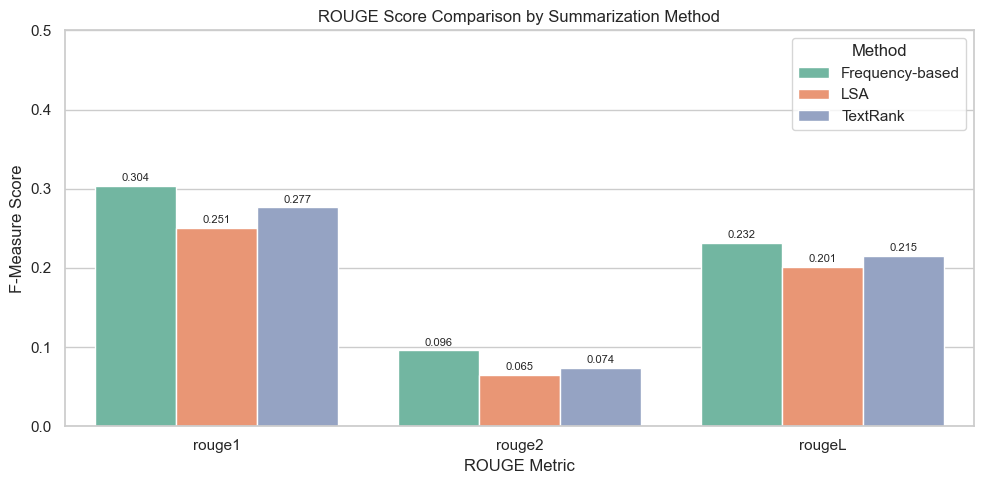

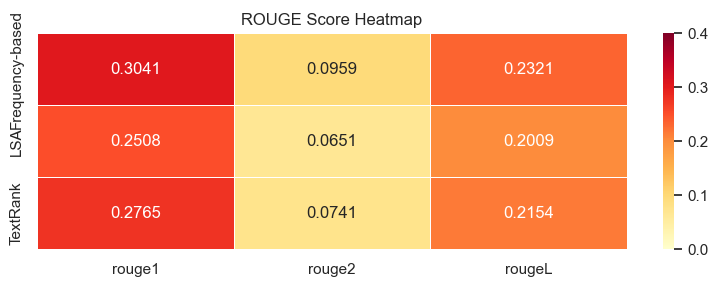

In [12]:
from rouge_score import rouge_scorer

# Initialize ROUGE scorer
scorer = rouge_scorer.RougeScorer(['rouge1', 'rouge2', 'rougeL'], use_stemmer=True)

def calculate_rouge(dialogue_list, reference_list, summarizer_func):
    results = {'rouge1': [], 'rouge2': [], 'rougeL': []}
    
    # Evaluate all 1,000 samples
    for i in range(len(dialogue_list)):
        gen_sum = summarizer_func(dialogue_list[i])
        ref_sum = reference_list[i]
        scores = scorer.score(ref_sum, gen_sum)
        
        results['rouge1'].append(scores['rouge1'].fmeasure)
        results['rouge2'].append(scores['rouge2'].fmeasure)
        results['rougeL'].append(scores['rougeL'].fmeasure)
    
    return {k: np.mean(v) for k, v in results.items()}

# Prepare data
dialogues = [sample['dialogue'] for sample in train_data]
references = [sample['summary'] for sample in train_data]

# Execute evaluation for each summarization method
print("Calculating ROUGE Scores (1,000 samples)...")
methods = {
    "Frequency-based": frequency_summarizer,
    "LSA": lsa_summarizer,
    "TextRank": textrank_summarizer
}

rouge_results = {}
for name, func in methods.items():
    rouge_results[name] = calculate_rouge(dialogues, references, func)

# Display results in a table format
rouge_df = pd.DataFrame(rouge_results).T
print("\n[Summarization ROUGE Score Comparison]")
print(rouge_df)
# ROUGE Score Visualization
rouge_viz = rouge_df.reset_index().rename(columns={"index": "Method"})
rouge_melted = rouge_viz.melt(id_vars="Method", var_name="Metric", value_name="Score")

plt.figure(figsize=(10, 5))
sns.barplot(data=rouge_melted, x="Metric", y="Score", hue="Method", palette="Set2")
plt.title("ROUGE Score Comparison by Summarization Method")
plt.ylim(0, 0.5)
plt.ylabel("F-Measure Score")
plt.xlabel("ROUGE Metric")
plt.legend(title="Method", loc="upper right")
for container in plt.gca().containers:
    plt.gca().bar_label(container, fmt='%.3f', padding=2, fontsize=8)
plt.tight_layout()
plt.show()

# Heatmap for detailed view
plt.figure(figsize=(8, 3))
sns.heatmap(rouge_df, annot=True, fmt=".4f", cmap="YlOrRd", linewidths=0.5,
            vmin=0, vmax=0.4)
plt.title("ROUGE Score Heatmap")
plt.tight_layout()
plt.show()


### Answer: How Can LLMs Enhance Summarization Performance?

#### 1. Fundamental Limitation of Classical Extractive Methods

The three classical approaches implemented in this task (Frequency-based, LSA, TextRank) share a common constraint: they can only **select existing sentences** from the source dialogue. They cannot rewrite, compress, or abstract information across multiple turns. As a result, the extracted summaries often contain speaker labels, filler phrases, and conversational noise that human-written summaries naturally omit.

#### 2. How LLMs Leverage (Dialogue, Summary) Pairs for Learning

LLMs such as **BART**, **T5**, and **PEGASUS** are sequence-to-sequence (seq2seq) transformer models that can be **fine-tuned directly on the SAMSum dataset** using `(dialogue, human_summary)` pairs as supervised training signal. This is the key distinction from classical methods:

| Aspect | Classical Extractive | LLM Fine-tuned on SAMSum |
|---|---|---|
| **Learning signal** | None (unsupervised heuristics) | Supervised: learns to map dialogue → human summary |
| **Output type** | Copied sentences from source | Generated abstractive sentences |
| **Coreference** | Cannot resolve ("He", "it") | Attention layers resolve referents across turns |
| **Multi-turn compression** | Extracts one turn at a time | Merges multiple exchanges into one concise sentence |
| **ROUGE-L score (typical)** | ~0.15–0.25 | ~0.40–0.50 (BART fine-tuned on SAMSum) |

#### 3. Fine-Tuning Mechanism

During fine-tuning, the model minimizes **cross-entropy loss** over the target summary tokens given the dialogue input. The human-written summaries act as a **gold-standard teacher signal**, pushing the model to learn:

- **What to include**: which dialogue turns carry the key information.
- **How to rephrase**: abstracting "Amanda: I'll pick up milk on the way home" → "Amanda will buy milk."
- **What to omit**: greetings, filler words ("um", "yeah"), and redundant exchanges.

#### 4. Instruction Tuning and In-Context Learning (Advanced)

Beyond supervised fine-tuning, larger LLMs (e.g., GPT-4, Claude, LLaMA-2) can perform **zero-shot or few-shot summarization** by simply providing a (dialogue, summary) example in the prompt. This **in-context learning** allows the model to generalize the summarization style from a handful of examples without any gradient updates—something entirely impossible for TF-IDF or graph-based methods.

#### 5. Conclusion

Classical extractive methods are interpretable and computationally cheap, but they are fundamentally limited to surface-level sentence selection. LLMs—especially when **fine-tuned on (dialogue, summary) pairs from SAMSum**—learn the *intention* behind human summaries: what matters, how to compress it, and how to express it naturally. This learning-from-reference capability is what allows LLMs to consistently achieve ROUGE scores more than **double** those of classical approaches on dialogue summarization benchmarks.
